In [39]:
import geopandas as gpd
import pandas as pd
import os
import matplotlib.pyplot as plt

In [40]:
# disease_version = sys.argv[-1]
disease_version = 'sf-v1'
log_dir = '../examples/logs/'
map_fn = 'atlanta' if 'atl' in disease_version else 'san-fran'
map_fn = '../examples/'+map_fn+'/region_census.shp'

In [41]:
if not os.path.exists(log_dir + disease_version + '/figures'):
    os.mkdir(log_dir + disease_version + '/figures')

In [42]:
single_bias = ['age', 'gender', 'income', 'race']
single_dir = 'single-bias-sampled/'
single_fn = single_dir + '%s_v%d.csv'
multi_fn = 'multi-biases-sampled/v%d.csv'

In [43]:
# Age group: 15(0), 20(1), 25(2), 30(3), 35(4), 40(5), 45(6), 50(7), 55(8), 60(9)
# IndiInc (Individual Income): 0(0), 10(1), 25(2), 50(3), 75(4), 100(5)
# Race: WhiteOnly(0), BlackOnly(1), AmerIndianOnly(2), AsianOnly(3), PacIslandOnly(4), Other(5), Plus2Races(6)
# Education: Unknown (0), Low (1), HighSchoolOrCollege (2), Bachelors (3), Graduate (4)
map_geo_df = gpd.read_file(map_fn) 
map_geo_df

,TrackId,TotPop,AgeGroup0,AgeGroup1,AgeGroup2,AgeGroup3,AgeGroup4,AgeGroup5,AgeGroup6,AgeGroup7,...,EduLevel3,EduLevel4,id,IndiInc0,IndiInc1,IndiInc2,IndiInc3,IndiInc4,IndiInc5,geometry
0,124.03,0.017723,0.056811,0.071472,0.119120,0.152108,0.105681,0.103238,0.108125,0.102627,...,0.199599,0.082247,1,0.000000,0.071247,0.201018,0.539440,0.068702,0.119593,"POLYGON ((-2658971.429 4826905.764, -2658812.2..."
1,124.04,0.031625,0.042006,0.079779,0.102898,0.137740,0.126669,0.118528,0.107782,0.106480,...,0.123620,0.035762,2,0.047407,0.257778,0.272593,0.225185,0.122963,0.074074,"POLYGON ((-2658812.294 4826865.367, -2658686.5..."
2,124.05,0.034114,0.018381,0.096022,0.254321,0.248011,0.125652,0.074623,0.045542,0.051852,...,0.514007,0.224421,3,0.023479,0.038812,0.136560,0.106373,0.091519,0.603258,"POLYGON ((-2659356.153 4826762.864, -2659341.8..."
3,124.06,0.015907,0.034303,0.055183,0.136465,0.155108,0.131245,0.120060,0.088740,0.093960,...,0.146288,0.132460,4,0.000000,0.111111,0.488889,0.000000,0.236364,0.163636,"POLYGON ((-2659297.761 4826990.902, -2659283.8..."
4,125.02,0.036826,0.028024,0.053835,0.074853,0.105088,0.096976,0.114676,0.091814,0.158555,...,0.066250,0.055118,5,0.042781,0.067736,0.456328,0.336898,0.057932,0.038324,"POLYGON ((-2658652.773 4826824.124, -2658640.8..."
5,125.03,0.035002,0.054728,0.062176,0.090674,0.113018,0.112047,0.111399,0.091969,0.121114,...,0.164453,0.070841,6,0.000000,0.163079,0.296358,0.370033,0.105960,0.064570,"POLYGON ((-2658711.608 4826596.022, -2658609.4..."
6,125.04,0.018709,0.015590,0.058463,0.103563,0.172049,0.115256,0.135857,0.069042,0.120824,...,0.081174,0.034542,7,0.000000,0.000000,0.614458,0.204819,0.102410,0.078313,"POLYGON ((-2658740.998 4826482.027, -2658581.0..."
7,159,0.038042,0.031677,0.122050,0.236957,0.168634,0.119876,0.077640,0.058075,0.061180,...,0.438407,0.183065,8,0.002000,0.099000,0.152500,0.173500,0.085000,0.488000,"POLYGON ((-2660494.228 4827568.291, -2660423.5..."
8,160,0.024394,0.017849,0.058713,0.158760,0.203852,0.153593,0.081259,0.078910,0.078441,...,0.271363,0.383076,9,0.020995,0.000000,0.077760,0.137636,0.131415,0.632193,"POLYGON ((-2659540.045 4827295.222, -2659510.6..."
9,161.01,0.022842,0.036799,0.088785,0.202103,0.170561,0.124416,0.080023,0.072430,0.063084,...,0.286901,0.264418,10,0.000000,0.139616,0.048866,0.024433,0.125654,0.661431,"POLYGON ((-2660599.535 4827205.107, -2660529.4..."


In [44]:
map_geo_df['Female'] = 1-map_geo_df['Male']
map_geo_df['Non-White'] = 1-map_geo_df['Race0']
map_geo_df['Income >= 50k'] = map_geo_df['IndiInc3']+map_geo_df['IndiInc4']+map_geo_df['IndiInc5']
map_geo_df['Age >= 50'] = map_geo_df['AgeGroup7']+map_geo_df['AgeGroup8']+map_geo_df['AgeGroup9']
map_geo_df['Edu >= Bachelors'] = map_geo_df['EduLevel2'] + map_geo_df['EduLevel3']
map_geo_df = map_geo_df[['TrackId', 'id', 'geometry', 'TotPop', 'Age >= 50', 'Female', 'Non-White', 'Income >= 50k', 'Edu >= Bachelors']].reset_index(drop=True)
map_geo_df

,TrackId,id,geometry,TotPop,Age >= 50,Female,Non-White,Income >= 50k,Edu >= Bachelors
0,124.03,1,"POLYGON ((-2658971.429 4826905.764, -2658812.2...",0.017723,0.283445,0.410756,0.750580,0.727735,0.494483
1,124.04,2,"POLYGON ((-2658812.294 4826865.367, -2658686.5...",0.031625,0.284598,0.351520,0.767212,0.422222,0.762031
2,124.05,3,"POLYGON ((-2659356.153 4826762.864, -2659341.8...",0.034114,0.137449,0.397158,0.559489,0.801150,0.713155
3,124.06,4,"POLYGON ((-2659297.761 4826990.902, -2659283.8...",0.015907,0.278896,0.412707,0.727789,0.400000,0.657205
4,125.02,5,"POLYGON ((-2658652.773 4826824.124, -2658640.8...",0.036826,0.434735,0.399822,0.781124,0.433155,0.523215
5,125.03,6,"POLYGON ((-2658711.608 4826596.022, -2658609.4...",0.035002,0.363990,0.393427,0.711972,0.540563,0.741935
6,125.04,7,"POLYGON ((-2658740.998 4826482.027, -2658581.0...",0.018709,0.330178,0.380764,0.620553,0.385542,0.352332
7,159,8,"POLYGON ((-2660494.228 4827568.291, -2660423.5...",0.038042,0.185093,0.493521,0.659179,0.746500,0.749670
8,160,9,"POLYGON ((-2659540.045 4827295.222, -2659510.6...",0.024394,0.247064,0.462108,0.573931,0.901244,0.531471
9,161.01,10,"POLYGON ((-2660599.535 4827205.107, -2660529.4...",0.022842,0.224883,0.536331,0.596403,0.811518,0.669599


In [45]:
agent_char_df = pd.read_csv(log_dir+disease_version+'/AgentCharacteristicsTable.tsv', sep='\t', engine="python")
simu_pop_count = agent_char_df.groupby('originRegionId').count()['agentId'].reset_index()
simu_pop_count = simu_pop_count.rename(columns={'originRegionId':'id', 'agentId':'simu-pop'})

In [46]:
map_geo_df=map_geo_df.merge(simu_pop_count, on='id', how='left')

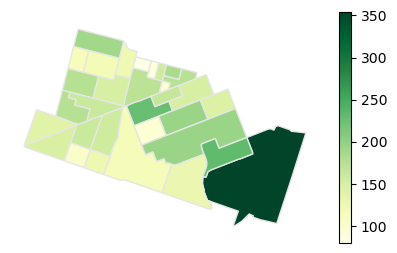

In [47]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='simu-pop', cmap='YlGn', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/simu_pop.pdf', bbox_inches='tight', format='pdf')

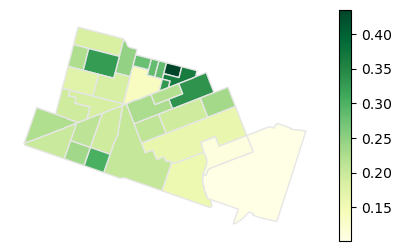

In [48]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='Age >= 50', cmap='YlGn', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/vulnerable.pdf', bbox_inches='tight', format='pdf')

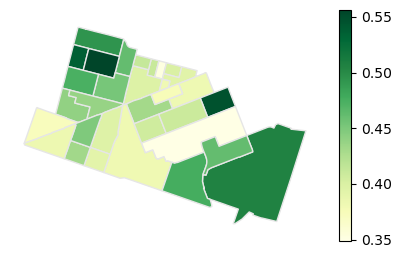

In [49]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='Female', cmap='YlGn', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/female.pdf', bbox_inches='tight', format='pdf')

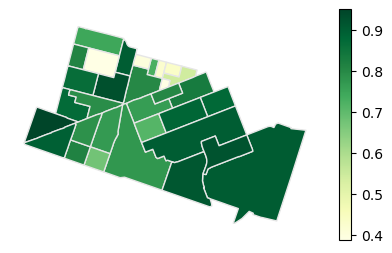

In [50]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='Income >= 50k', cmap='YlGn', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/rich.pdf', bbox_inches='tight', format='pdf')

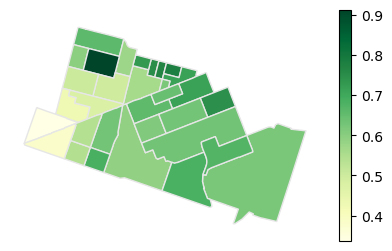

In [51]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='Non-White', cmap='YlGn', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/non-white.pdf', bbox_inches='tight', format='pdf')

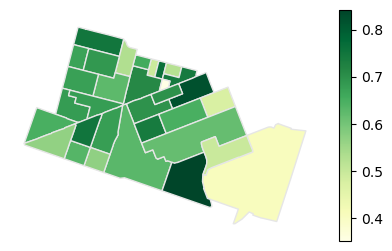

In [52]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='Edu >= Bachelors', cmap='YlGn', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/high-edu.pdf', bbox_inches='tight', format='pdf')

In [53]:
disease_truth_df = pd.read_csv(log_dir+disease_version+'/DiseaseStatusChangeJournal.tsv', sep='\t|,', engine="python")
disease_truth_df = disease_truth_df[disease_truth_df['diseaseStatus'] == 'Infectious'].reset_index(drop=True)
disease_truth_df['id'] = disease_truth_df['[regionId'].apply(lambda x : int(x[1:]))
disease_truth_count_df = disease_truth_df.groupby('id').count()['agentId'].reset_index()
disease_truth_count_df = disease_truth_count_df.rename(columns={'agentId':'total infectious'})
map_geo_df = map_geo_df.merge(disease_truth_count_df, on='id')
map_geo_df['total infectious'] = map_geo_df['total infectious'] / map_geo_df['simu-pop']
map_geo_df

,TrackId,id,geometry,TotPop,Age >= 50,Female,Non-White,Income >= 50k,Edu >= Bachelors,simu-pop,total infectious
0,124.03,1,"POLYGON ((-2658971.429 4826905.764, -2658812.2...",0.017723,0.283445,0.410756,0.750580,0.727735,0.494483,89,0.719101
1,124.04,2,"POLYGON ((-2658812.294 4826865.367, -2658686.5...",0.031625,0.284598,0.351520,0.767212,0.422222,0.762031,158,0.759494
2,124.05,3,"POLYGON ((-2659356.153 4826762.864, -2659341.8...",0.034114,0.137449,0.397158,0.559489,0.801150,0.713155,171,0.771930
3,124.06,4,"POLYGON ((-2659297.761 4826990.902, -2659283.8...",0.015907,0.278896,0.412707,0.727789,0.400000,0.657205,80,0.862500
4,125.02,5,"POLYGON ((-2658652.773 4826824.124, -2658640.8...",0.036826,0.434735,0.399822,0.781124,0.433155,0.523215,184,0.722826
5,125.03,6,"POLYGON ((-2658711.608 4826596.022, -2658609.4...",0.035002,0.363990,0.393427,0.711972,0.540563,0.741935,175,0.668571
6,125.04,7,"POLYGON ((-2658740.998 4826482.027, -2658581.0...",0.018709,0.330178,0.380764,0.620553,0.385542,0.352332,94,0.531915
7,159,8,"POLYGON ((-2660494.228 4827568.291, -2660423.5...",0.038042,0.185093,0.493521,0.659179,0.746500,0.749670,190,0.789474
8,160,9,"POLYGON ((-2659540.045 4827295.222, -2659510.6...",0.024394,0.247064,0.462108,0.573931,0.901244,0.531471,122,0.819672
9,161.01,10,"POLYGON ((-2660599.535 4827205.107, -2660529.4...",0.022842,0.224883,0.536331,0.596403,0.811518,0.669599,114,0.912281


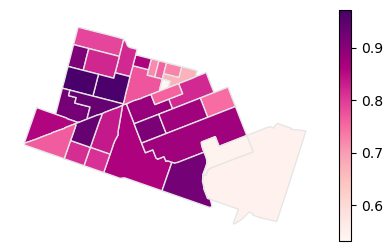

In [54]:
fig, ax = plt.subplots(1, figsize=(5,3))
map_geo_df.plot(column='total infectious', cmap='RdPu', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
ax.axis('off')
fig.savefig(log_dir + disease_version + '/figures/true_infectious.pdf', bbox_inches='tight', format='pdf')

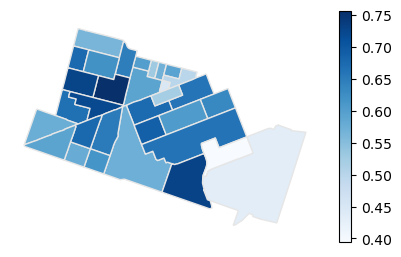

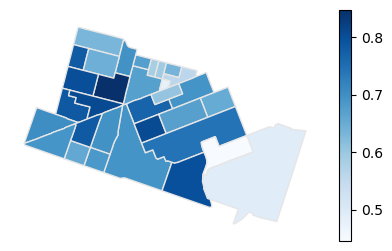

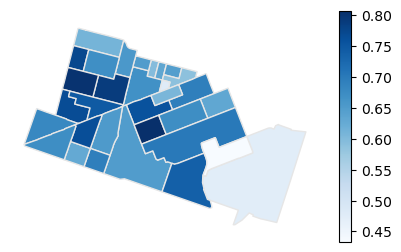

In [55]:
if not os.path.exists(log_dir + disease_version + '/figures/multi-biases'):
    os.mkdir(log_dir + disease_version + '/figures/multi-biases')

for i in range(1,4):
    biased_disease_df = pd.read_csv(log_dir + disease_version+'/multi-biases-sampled/v%d.csv'%i, sep='\t|,', engine="python")
    biased_disease_df = biased_disease_df[biased_disease_df['diseaseStatus'] == 'Infectious'].reset_index(drop=True)
    biased_disease_df['id'] = biased_disease_df['[regionId'].apply(lambda x : int(x[1:]))
    biased_disease_df = biased_disease_df.groupby('id').count()['agentId'].reset_index()
    biased_disease_df = biased_disease_df.rename(columns={'agentId':'reported infectious'})
    map_geo_bias_df = map_geo_df.merge(biased_disease_df, on='id')
    map_geo_bias_df['reported infectious'] = map_geo_bias_df['reported infectious'] / map_geo_bias_df['simu-pop']
    
    fig, ax = plt.subplots(1, figsize=(5,3))
    map_geo_bias_df.plot(column='reported infectious', cmap='Blues', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
    ax.axis('off')
    fig.savefig(log_dir + disease_version + '/figures/multi-biases/v%d_reported.pdf'%i, bbox_inches='tight', format='pdf')

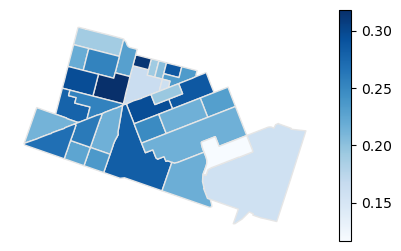

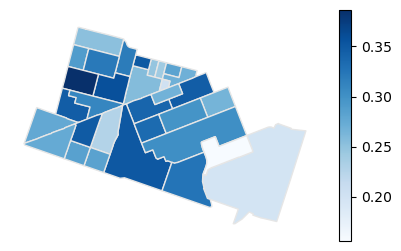

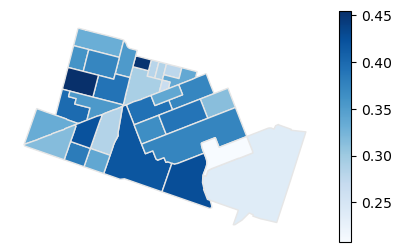

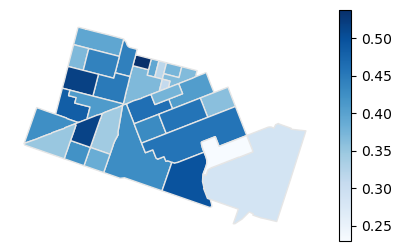

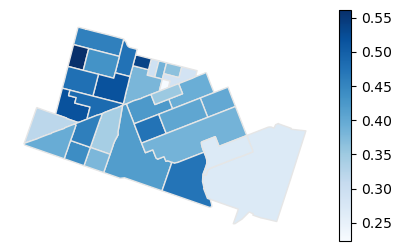

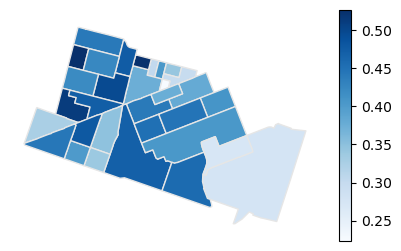

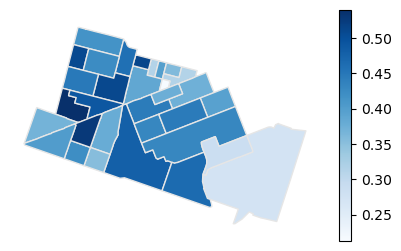

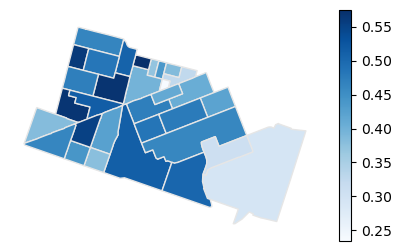

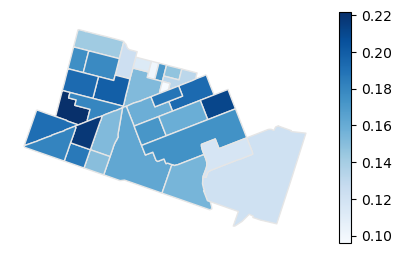

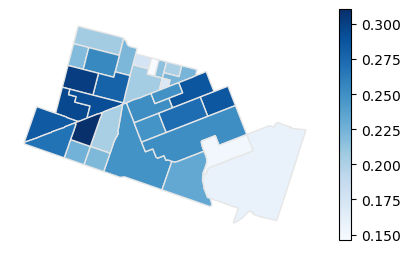

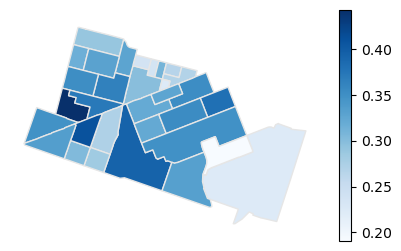

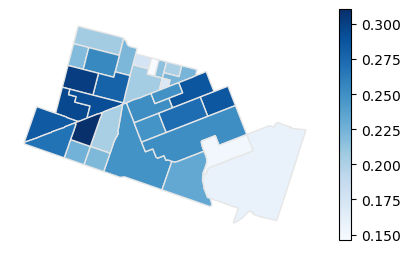

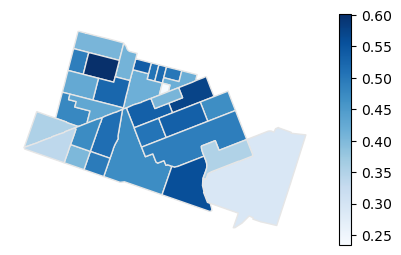

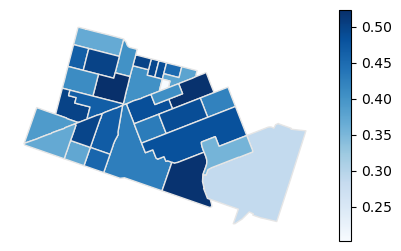

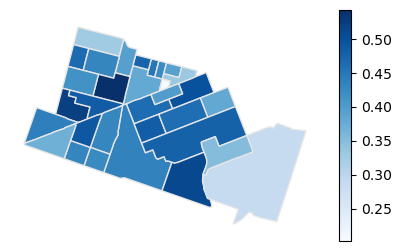

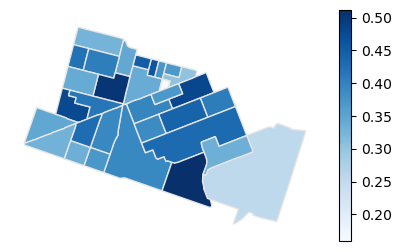

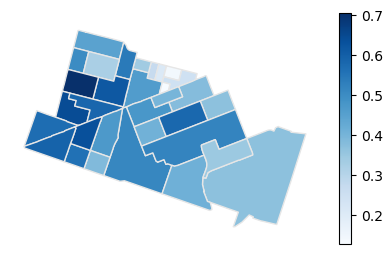

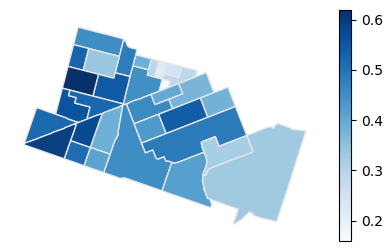

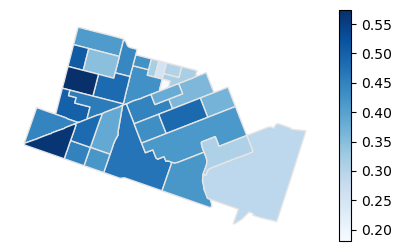

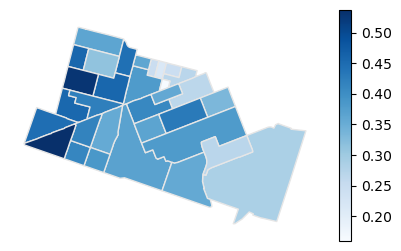

In [56]:
if not os.path.exists(log_dir + disease_version + '/figures/single-bias'):
    os.mkdir(log_dir + disease_version + '/figures/single-bias')

bias_types = ['age','gender','income','race','edu']
for bt in bias_types:
    if not os.path.exists(log_dir + disease_version + '/figures/single-bias/%s'%bt):
        os.mkdir(log_dir + disease_version + '/figures/single-bias/%s'%bt)

    for i in range(1,5):
        biased_disease_df = pd.read_csv(log_dir + disease_version+'/single-bias-sampled/%s_v%d.csv'%(bt,i), sep='\t|,', engine="python")
        biased_disease_df = biased_disease_df[biased_disease_df['diseaseStatus'] == 'Infectious'].reset_index(drop=True)
        biased_disease_df['id'] = biased_disease_df['[regionId'].apply(lambda x : int(x[1:]))
        biased_disease_df = biased_disease_df.groupby('id').count()['agentId'].reset_index()
        biased_disease_df = biased_disease_df.rename(columns={'agentId':'reported infectious'})
        map_geo_bias_df = map_geo_df.merge(biased_disease_df, on='id')
        map_geo_bias_df['reported infectious'] = map_geo_bias_df['reported infectious'] / map_geo_bias_df['simu-pop']
        
    
        fig, ax = plt.subplots(1, figsize=(5,3))
        map_geo_bias_df.plot(column='reported infectious', cmap='Blues', ax=ax, linewidth=1, edgecolor='0.9', legend=True)
        ax.axis('off')
        fig.savefig(log_dir + disease_version + '/figures/single-bias/%s/v%d_reported.pdf'%(bt,i), bbox_inches='tight', format='pdf')